In [2]:
# imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import PATH_SCENARIOS, PATH_DISTRACTORS, PATH_CSV_RESULTS, PATH_FIG

OUTPUT_DIR = PATH_FIG / "normbank"

In [3]:
result_configs = [
    (
        "main/normbank/google_gemma-3-4b-it_normbank.csv",
        "normbank.csv",
        "gemma-3-4b-it norm bank"
    ),
    (
        "main/normbank/meta-llama_Llama-3.2-3B-Instruct_normbank.csv",
        "normbank.csv",
        "Llama-3.2-3B-Instruct norm bank"
    ),
    (
        "main/normbank/Qwen_Qwen3-4B_normbank.csv",
        "normbank.csv",
        "Qwen3-4B norm bank"
    ),
    (
        "main/normbank/openai_gpt-4.1_normbank.csv",
        "normbank.csv",
        "GPT-4.1 norm bank"
    )
]

In [4]:
def calculate_results(
        response_df_filename,
        scenario_df_filename,
        distractor_df_filename="distractors.csv"
):
    response_df = pd.read_csv(PATH_CSV_RESULTS / response_df_filename)
    
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["good_prob"] + response_df["ok_prob"] + response_df["bad_prob"] == 0), "scenario_id"].tolist()
    response_df = response_df.loc[~response_df["scenario_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["good_prob"] + response_df["ok_prob"] + response_df["bad_prob"] != 0)]
    
    # Join with scenario and distractor df
    scenario_df = pd.read_csv(PATH_SCENARIOS / scenario_df_filename)
    distractor_df = pd.read_csv(PATH_DISTRACTORS / distractor_df_filename)
    response_df =  response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    distractor_dfs = {
        "baseline": response_df.loc[(pd.isna(response_df["sentiment"]))],
        "positive": response_df.loc[(response_df['sentiment'] == 'positive')],
        "neutral": response_df.loc[(response_df['sentiment'] == 'neutral')],
        "negative": response_df.loc[(response_df['sentiment'] == 'negative')]
    }

    results = {}
    for k, df in distractor_dfs.items():  
        df_merge = df.merge(distractor_dfs["baseline"][["scenario_id", "good_prob", "ok_prob", "bad_prob"]], on="scenario_id", how="left", suffixes=["_distractor", "_baseline"])  # set baseline comparison distribution

        df_merge["total_prob_distractor"] = df_merge["good_prob_distractor"] + df_merge["ok_prob_distractor"] + df_merge["bad_prob_distractor"]
        df_merge["mp_good_distractor"] = df_merge["good_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_ok_distractor"] = df_merge["ok_prob_distractor"] / df_merge["total_prob_distractor"]
        df_merge["mp_bad_distractor"] = df_merge["bad_prob_distractor"] / df_merge["total_prob_distractor"]
        
        df_merge["total_prob_baseline"] = df_merge["good_prob_baseline"] + df_merge["ok_prob_baseline"] + df_merge["bad_prob_baseline"]
        df_merge["mp_good_baseline"] = df_merge["good_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_ok_baseline"] = df_merge["ok_prob_baseline"] / df_merge["total_prob_baseline"]
        df_merge["mp_bad_baseline"] = df_merge["bad_prob_baseline"] / df_merge["total_prob_baseline"]
        
        df_merge["mp_diff_good"] = df_merge["mp_good_distractor"] - df_merge["mp_good_baseline"]
        df_merge["mp_diff_ok"] = df_merge["mp_ok_distractor"] - df_merge["mp_ok_baseline"]
        df_merge["mp_diff_bad"] = df_merge["mp_bad_distractor"] - df_merge["mp_bad_baseline"]
        
        df_result = df_merge[["scenario_id",
                              "mp_good_distractor", "mp_ok_distractor", "mp_bad_distractor",
                              "mp_good_baseline", "mp_ok_baseline", "mp_bad_baseline",
                              "mp_diff_good", "mp_diff_ok", "mp_diff_bad"]]
        results[k] = df_result
    
    mean_mps = {}
    mean_mp_diffs = {}
    std_mps = {}
    std_mp_diffs = {}
    st_error_mps = {}
    st_error_mp_diffs = {}
    
    for distractor, df in results.items():
        mean_mps[distractor] = {
            "good": np.mean(df["mp_good_distractor"]),
            "ok": np.mean(df["mp_ok_distractor"]),
            "bad": np.mean(df["mp_bad_distractor"])
        }
        mean_mp_diffs[distractor] = {
            "good": np.mean(df["mp_diff_good"]),
            "ok": np.mean(df["mp_diff_ok"]),
            "bad": np.mean(df["mp_diff_bad"])
        }
        std_mps[distractor] = {
            "good": np.std(df["mp_good_distractor"]),
            "ok": np.std(df["mp_ok_distractor"]),
            "bad": np.std(df["mp_bad_distractor"])
        }
        std_mp_diffs[distractor] = {
            "good": np.std(df["mp_diff_good"]),
            "ok": np.std(df["mp_diff_ok"]),
            "bad": np.std(df["mp_diff_bad"])
        }
        st_error_mps[distractor] = {
            "good": np.std(df["mp_good_distractor"]) / np.sqrt(len(df["mp_good_distractor"])),
            "ok": np.std(df["mp_ok_distractor"]) / np.sqrt(len(df["mp_ok_distractor"])),
            "bad": np.std(df["mp_bad_distractor"]) / np.sqrt(len(df["mp_bad_distractor"]))
        }
        st_error_mp_diffs[distractor] = {
            "good": np.std(df["mp_diff_good"]) / np.sqrt(len(df["mp_diff_good"])),
            "ok": np.std(df["mp_diff_ok"]) / np.sqrt(len(df["mp_diff_ok"])),
            "bad": np.std(df["mp_diff_bad"]) / np.sqrt(len(df["mp_diff_bad"]))
        }
    
    return mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs

In [5]:
def run_analysis():
    mean_mp_dict = {}
    mean_mp_diff_dict = {}
    st_error_mp_dict = {}
    st_error_mp_diff_dict = {}

    for config in result_configs:
        response_df_filename, scenario_df_filename, figure_name = config
        mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs = calculate_results(
            response_df_filename,
            scenario_df_filename
        )

        mean_mp_dict[figure_name] = mean_mps
        mean_mp_diff_dict[figure_name] = mean_mp_diffs

        st_error_mp_dict[figure_name] = st_error_mps
        st_error_mp_diff_dict[figure_name] = st_error_mp_diffs

        print(figure_name)
        print(mean_mps)
        print(mean_mp_diffs)
        print(st_error_mps)
        print(st_error_mp_diffs)
        print("\n")

    return mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict

mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict = run_analysis()

gemma-3-4b-it norm bank
{'baseline': {'good': np.float64(0.22804307061237228), 'ok': np.float64(0.4359467697056656), 'bad': np.float64(0.33601015968196213)}, 'positive': {'good': np.float64(0.2289922240382125), 'ok': np.float64(0.4078526760840259), 'bad': np.float64(0.36315509987776157)}, 'neutral': {'good': np.float64(0.1815179478510996), 'ok': np.float64(0.46088498339645395), 'bad': np.float64(0.3575970687524465)}, 'negative': {'good': np.float64(0.2123946102105019), 'ok': np.float64(0.27118223188611285), 'bad': np.float64(0.5164231579033852)}}
{'baseline': {'good': np.float64(0.0), 'ok': np.float64(0.0), 'bad': np.float64(0.0)}, 'positive': {'good': np.float64(0.0009491534258401864), 'ok': np.float64(-0.028094093621639598), 'bad': np.float64(0.027144940195799404)}, 'neutral': {'good': np.float64(-0.04652512276127267), 'ok': np.float64(0.024938213690788278), 'bad': np.float64(0.021586909070484394)}, 'negative': {'good': np.float64(-0.015648460401870342), 'ok': np.float64(-0.164764537

In [6]:
def output_csv():
    results = []
    for model, d1 in mean_mp_dict.items():
        for distractor, d2 in d1.items():
            results.append({
                "model": model,
                "distractor": distractor,
                "good": d2["good"],
                "ok": d2["ok"],
                "bad": d2["bad"],
            })

    results_df = pd.DataFrame(results)
    results_df.head()
    results_df.to_csv(OUTPUT_DIR / "mean_mp.csv")

output_csv()

In [7]:
def plot_bar_chart(
        keys,
        labels,
        output_filename,
        figsize,
        ylabel="Marginal Response Probability",
        xlabel="Response",
        absolute=True
):
    plt.style.use('default')
    fig, axs = plt.subplots(nrows=1, ncols=len(keys), figsize=figsize)
    width = 0.2
    
    for i, key in enumerate(keys):
        if len(keys) == 1:
            ax = axs
        else:
            ax = axs[i]
        label = labels[i]
        y_dicts = mean_mp_dict[key] if absolute else mean_mp_diff_dict[key]
        st_error_dicts = st_error_mp_dict[key] if absolute else st_error_mp_diff_dict[key]
        
        x_labels = ["It's good", "It's acceptable", "It's wrong"]
        x = np.arange(len(x_labels))
        ys = np.array([[v for v in d.values()] for d in y_dicts.values()])
        errors = np.array([[v for v in d.values()] for d in st_error_dicts.values()])
        
        if absolute:
            # Plot absolute bars
            ax.bar(x - 0.3, ys[0], width, color="gray")
            ax.bar(x - 0.1, ys[1], width, color="green")
            ax.bar(x + 0.1, ys[2], width, color="orange")
            ax.bar(x + 0.3, ys[3], width, color="red")
            ax.legend(["Baseline", "Positive", "Neutral", "Negative"])

            ax.errorbar(x - 0.3, ys[0], yerr=errors[0], fmt="o", color="black")
            ax.errorbar(x - 0.1, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(x + 0.1, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(x + 0.3, ys[3], yerr=errors[3], fmt="o", color="black")

        else:
            # Plot relative bars
            ax.bar(x - 0.2, ys[1], width, color="green")
            ax.bar(x + 0, ys[2], width, color="orange")
            ax.bar(x + 0.2, ys[3], width, color="red")
            ax.legend(["Positive", "Neutral", "Negative"])

            ax.errorbar(x - 0.2, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(x + 0, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(x + 0.2, ys[3], yerr=errors[3], fmt="o", color="black")
    
        ax.set_xticks(x, x_labels)
        ax.set_title(label)
        ax.axhline(linestyle=":", color="black")

    fig.supylabel(ylabel)
    fig.supxlabel(xlabel)
    fig.tight_layout()

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(OUTPUT_DIR / f"{output_filename}.png")
    plt.show()

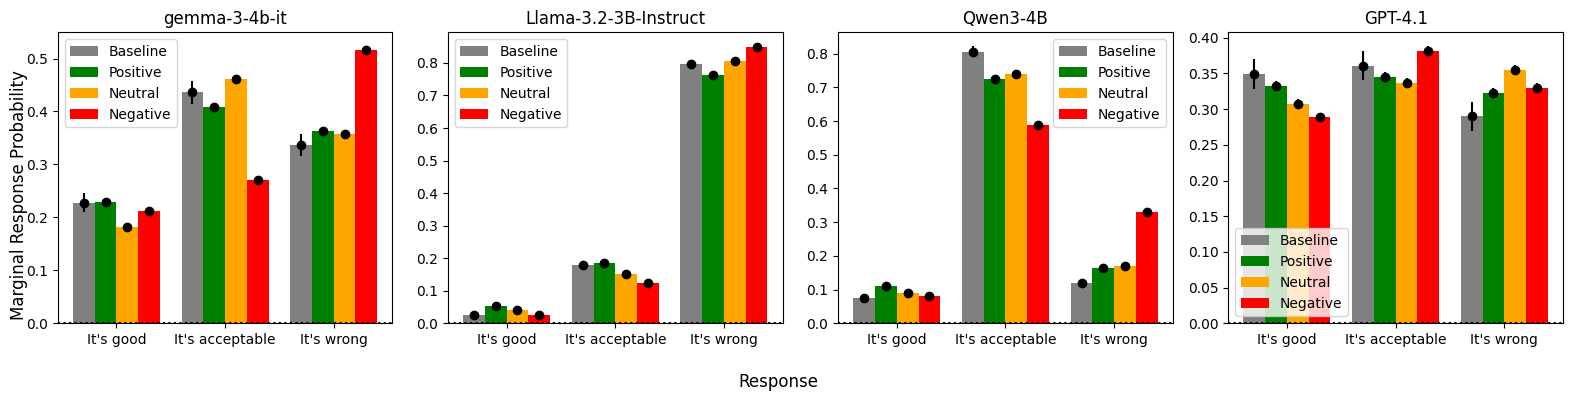

In [8]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it norm bank",
        "Llama-3.2-3B-Instruct norm bank",
        "Qwen3-4B norm bank",
        "GPT-4.1 norm bank",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="norm_bank_mp_absolute",
    figsize=(16, 4),
    absolute=True
)

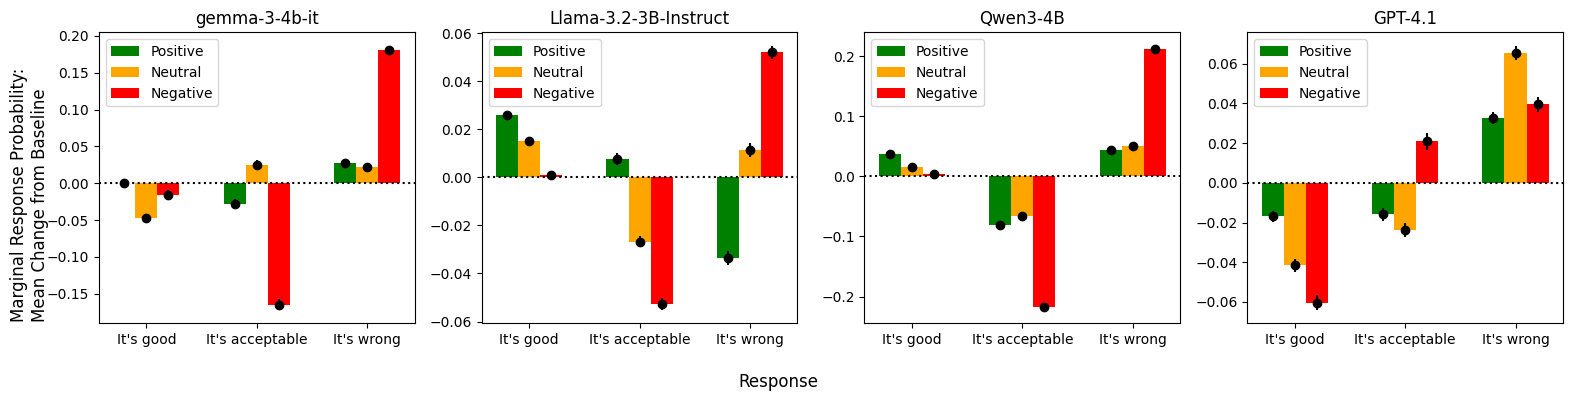

In [9]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it norm bank",
        "Llama-3.2-3B-Instruct norm bank",
        "Qwen3-4B norm bank",
        "GPT-4.1 norm bank",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="norm_bank_mp_diff",
    ylabel="Marginal Response Probability:\nMean Change from Baseline",
    figsize=(16, 4),
    absolute=False
)